In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once Google Drive is mounted, you can access your files. Replace `'/content/drive/My Drive/path/to/your/data.csv'` with the actual path to your data file.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import friedmanchisquare, wilcoxon, spearmanr
from statsmodels.stats.multitest import multipletests 


sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 12,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'figure.titlesize': 13
})


file_configs = [
    {"model": "mDeBERTa-v3 (Encoder)", "lang": "ENG", "path": "/content/drive/MyDrive/xai_project/mdeberta_results (1)/core3_eng_results (1).csv"},
    {"model": "mDeBERTa-v3 (Encoder)", "lang": "AFR", "path": "/content/drive/MyDrive/xai_project/mdeberta_results (1)/core3_afr_results (1).csv"},
    {"model": "mDeBERTa-v3 (Encoder)", "lang": "JAV", "path": "/content/drive/MyDrive/xai_project/mdeberta_results (1)/core3_jav_results (1).csv"},
    {"model": "Qwen-0.5B (Decoder)",    "lang": "ENG", "path": "/content/drive/MyDrive/xai_project/qwen_results (1)/core3_eng_results (1).csv"},
    {"model": "Qwen-0.5B (Decoder)",    "lang": "AFR", "path": "/content/drive/MyDrive/xai_project/qwen_results (1)/core3_afr_results (1).csv"},
    {"model": "Qwen-0.5B (Decoder)",    "lang": "JAV", "path": "/content/drive/MyDrive/xai_project/qwen_results (1)/core3_jav_results (1).csv"},
]

all_dfs = []
for config in file_configs:
    if os.path.exists(config["path"]):
        df = pd.read_csv(config["path"])
        df['method'] = df['method'].str.strip().str.upper()
        df['language'] = config["lang"]
        df['model_type'] = config["model"]
        all_dfs.append(df)

master_df = pd.concat(all_dfs, ignore_index=True)
method_mapping = {'LOO': 'LOO', 'SHAP': 'SHAP', 'LIME': 'LIME', 'MARGINALIZATION': 'Marg', 'PLEX': 'PLEX'}
master_df['method'] = master_df['method'].map(method_mapping).fillna(master_df['method'])
methods_list = ['LOO', 'SHAP', 'LIME', 'Marg', 'PLEX']


pivot_cols = ['model_type', 'language', 'row_index', 'label_idx', 'token_count', 'text_snippet']
df_wide = master_df.pivot_table(index=pivot_cols, columns='method', values='naopc').reset_index()

print(f"✅ 严谨版数据清洗完毕。总实例数: {len(master_df)}")

✅ 严谨版数据清洗完毕。总实例数: 1050



=== Table 1: Overall Performance Metrics (Mean ± SEM) ===
           model_type method  Mean_NAOPC  SEM_NAOPC  Mean_Time  SEM_Time
  Qwen-0.5B (Decoder)   LIME      0.3362     0.0155   212.3387    3.2649
  Qwen-0.5B (Decoder)    LOO      0.3362     0.0155     1.5232    0.0970
  Qwen-0.5B (Decoder)   Marg      0.3018     0.0164     6.6941    0.4785
  Qwen-0.5B (Decoder)   PLEX      0.3342     0.0161     5.9993    0.4312
  Qwen-0.5B (Decoder)   SHAP      0.3406     0.0175    10.6258    0.9967
mDeBERTa-v3 (Encoder)   LIME      0.3723     0.0199   103.4758    0.5550
mDeBERTa-v3 (Encoder)    LOO      0.3723     0.0199     0.6953    0.0294
mDeBERTa-v3 (Encoder)   Marg      0.3286     0.0202     3.9229    0.1822
mDeBERTa-v3 (Encoder)   PLEX      0.3651     0.0202     3.6102    0.1682
mDeBERTa-v3 (Encoder)   SHAP      0.3425     0.0196     4.5312    0.3041


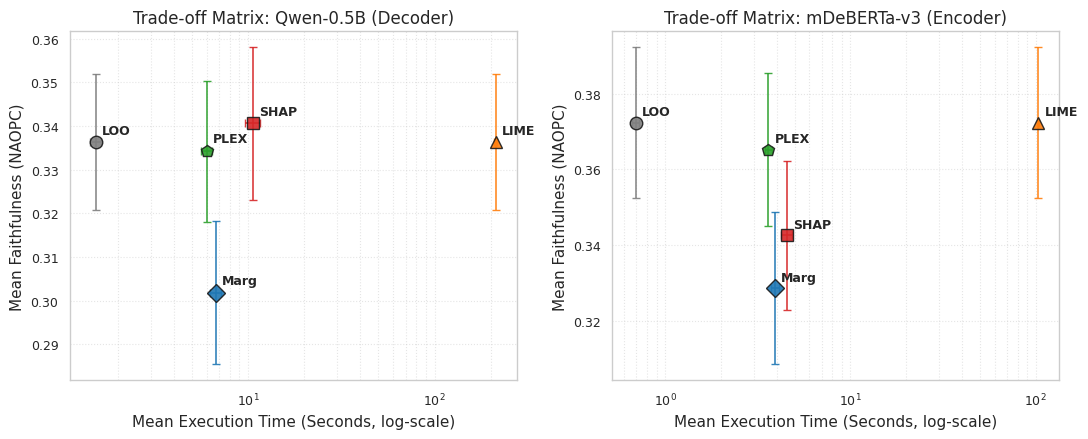

In [ ]:
# [Table 1] 
table_1 = master_df.groupby(['model_type', 'method']).agg(
    Mean_NAOPC=('naopc', 'mean'), SEM_NAOPC=('naopc', 'sem'),
    Mean_Time=('elapsed_time_seconds', 'mean'), SEM_Time=('elapsed_time_seconds', 'sem')
).reset_index()
print("\n=== Table 1: Overall Performance Metrics (Mean ± SEM) ===")
print(table_1.round(4).to_string(index=False))

# [Figure 1] 
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {'LOO': '#7f7f7f', 'SHAP': '#d62728', 'LIME': '#ff7f0e', 'Marg': '#1f77b4', 'PLEX': '#2ca02c'}
markers = {'LOO': 'o', 'SHAP': 's', 'LIME': '^', 'Marg': 'D', 'PLEX': 'p'}

for i, model in enumerate(table_1['model_type'].unique()):
    ax = axes[i]
    sub_df = table_1[table_1['model_type'] == model]
    for _, row in sub_df.iterrows():
        ax.errorbar(
            row['Mean_Time'], row['Mean_NAOPC'], xerr=row['SEM_Time'], yerr=row['SEM_NAOPC'],
            fmt=markers[row['method']], color=colors[row['method']], markersize=9,
            elinewidth=1.2, capsize=3, alpha=0.9, markeredgecolor='k', label=row['method']
        )
        ax.text(row['Mean_Time'] * 1.08, row['Mean_NAOPC'] + 0.002, row['method'], fontsize=9, weight='bold')
    ax.set_title(f"Trade-off Matrix: {model}")
    ax.set_xlabel("Mean Execution Time (Seconds, log-scale)")
    ax.set_ylabel("Mean Faithfulness (NAOPC)")
    ax.set_xscale('log')
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("Figure_1_runtime_vs_faithfulness.png", dpi=300)
plt.show()


=== Table 3: Resource Drop Analysis (Absolute & Relative) ===
language                         ENG     AFR     JAV  Abs_Drop (ENG-JAV)  Rel_Drop (ENG-JAV) %
model_type            method                                                                  
Qwen-0.5B (Decoder)   LIME    0.3917  0.3165  0.3006              0.0911               23.2657
                      LOO     0.3917  0.3165  0.3006              0.0911               23.2657
                      Marg    0.3511  0.2824  0.2721              0.0790               22.5004
                      PLEX    0.3850  0.3239  0.2937              0.0913               23.7148
                      SHAP    0.3983  0.3254  0.2980              0.1004               25.1966
mDeBERTa-v3 (Encoder) LIME    0.3963  0.3817  0.3390              0.0572               14.4364
                      LOO     0.3963  0.3817  0.3390              0.0572               14.4364
                      Marg    0.3341  0.3328  0.3188              0.0153          

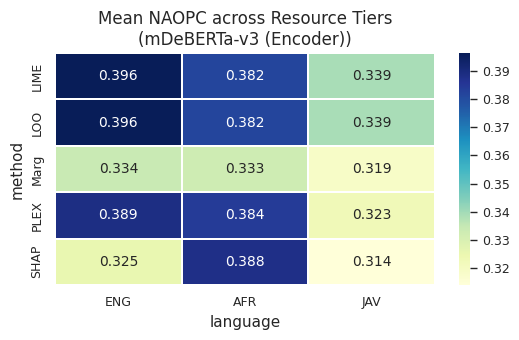

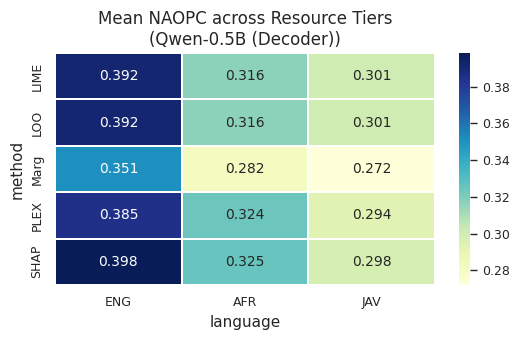

In [ ]:

resource_mean = master_df.groupby(['model_type', 'method', 'language'])['naopc'].mean().unstack(level='language')[['ENG', 'AFR', 'JAV']]

# [Table 3] 
table_3 = resource_mean.copy()
table_3['Abs_Drop (ENG-JAV)'] = table_3['ENG'] - table_3['JAV']
table_3['Rel_Drop (ENG-JAV) %'] = (table_3['Abs_Drop (ENG-JAV)'] / table_3['ENG']) * 100

print("\n=== Table 3: Resource Drop Analysis (Absolute & Relative) ===")
print(table_3.round(4).to_string())

# [Figure 2] 
for model in master_df['model_type'].unique():
    plt.figure(figsize=(5.5, 3.5))
    sns.heatmap(resource_mean.loc[model], annot=True, fmt=".3f", cmap="YlGnBu", cbar=True, linewidths=.3)
    plt.title(f"Mean NAOPC across Resource Tiers\n({model})")
    plt.tight_layout()
    plt.savefig(f"Figure_2_resource_heatmap_{model.split()[0].lower()}.png", dpi=300)
    plt.show()

In [ ]:

import pandas as pd
from scipy.stats import wilcoxon, norm
from statsmodels.stats.multitest import multipletests

print("\n" + "="*70 + "\n🎲 Table 2: Statistical Significance & Effect Sizes (vs. SHAP Gold Standard)\n" + "="*70)

df_test = master_df.pivot_table(index=['model_type', 'language', 'row_index', 'label_idx'],
                                 columns='method',
                                 values='naopc').dropna()

for model in df_test.index.get_level_values('model_type').unique():
    model_df = df_test.xs(model, level='model_type')
    N = len(model_df) 

    comparisons = ['LOO', 'LIME', 'Marg', 'PLEX']
    p_values_raw = []
    effect_sizes = []

    for m in comparisons:
        res = wilcoxon(model_df['SHAP'], model_df[m], method='approx')
        p_values_raw.append(res.pvalue)

        z_score = norm.ppf(1 - res.pvalue / 2) if 0 < res.pvalue < 1 else 0

        r_effect = z_score / np.sqrt(N)
        effect_sizes.append(r_effect)

    reject, p_adjusted, _, _ = multipletests(p_values_raw, alpha=0.05, method='bonferroni')

    print(f"\n【模型架构: {model}】 (样本对数 N = {N})")
    print(f"{'对比组合 (Baseline: SHAP)':<25} | {'原始 p 值':<11} | {'校正后 p 值':<12} | {'效应量 (r)':<11} | {'结论 (Verdict)'}")
    print("-" * 85)
    for idx, m in enumerate(comparisons):
        verdict = "✨ Significant" if reject[idx] else "❌ Not Sig."
        print(f"SHAP vs {m:<18} | {p_values_raw[idx]:.4e} | {p_adjusted[idx]:.4e} | {effect_sizes[idx]:.4f} {' '*3} | {verdict}")
    print("-" * 85)


🎲 Table 2: Statistical Significance & Effect Sizes (vs. SHAP Gold Standard)

【模型架构: Qwen-0.5B (Decoder)】 (样本对数 N = 60)
对比组合 (Baseline: SHAP)     | 原始 p 值      | 校正后 p 值      | 效应量 (r)     | 结论 (Verdict)
-------------------------------------------------------------------------------------
SHAP vs LOO                | 4.8101e-01 | 1.0000e+00 | 0.0910     | ❌ Not Sig.
SHAP vs LIME               | 4.8101e-01 | 1.0000e+00 | 0.0910     | ❌ Not Sig.
SHAP vs Marg               | 5.6408e-03 | 2.2563e-02 | 0.3573     | ✨ Significant
SHAP vs PLEX               | 5.9609e-01 | 1.0000e+00 | 0.0684     | ❌ Not Sig.
-------------------------------------------------------------------------------------

【模型架构: mDeBERTa-v3 (Encoder)】 (样本对数 N = 150)
对比组合 (Baseline: SHAP)     | 原始 p 值      | 校正后 p 值      | 效应量 (r)     | 结论 (Verdict)
-------------------------------------------------------------------------------------
SHAP vs LOO                | 1.1294e-02 | 4.5176e-02 | 0.2069     | ✨ Significant
SHAP vs


📌 正在导出附录材料 (Appendix: Length Sensitivity & Correlation Matrix)


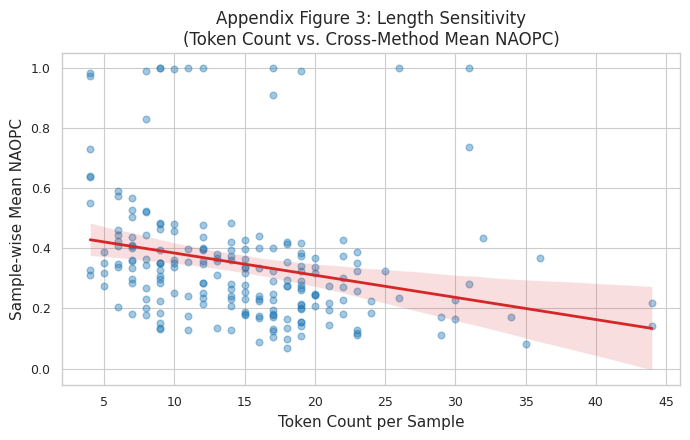

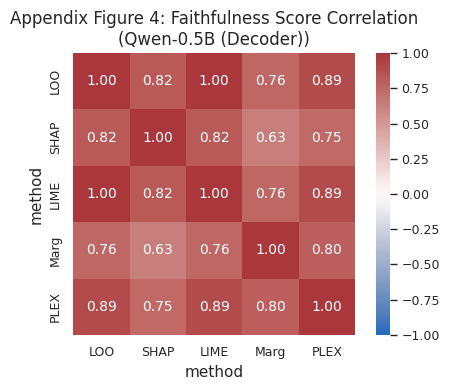

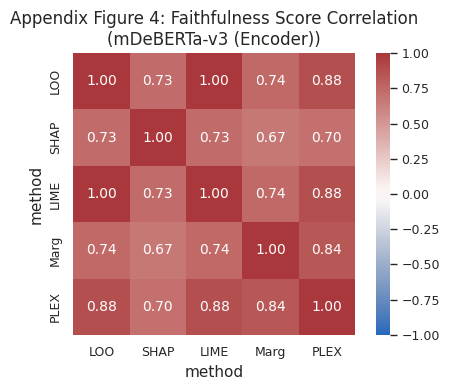

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

print("\n" + "="*70 + "\n📌 正在导出附录材料 (Appendix: Length Sensitivity & Correlation Matrix)\n" + "="*70)

methods_list = ['LOO', 'SHAP', 'LIME', 'Marg', 'PLEX']
df_wide['mean_score'] = df_wide[methods_list].mean(axis=1)

# --- [Appendix Figure 3] Length Sensitivity Regression Plot ---
plt.figure(figsize=(7, 4.5))
sns.regplot(data=df_wide, x='token_count', y='mean_score',
            scatter_kws={'alpha':0.4, 'color':'#1f77b4'}, line_kws={'color':'#d62728', 'lw':2})
plt.title("Appendix Figure 3: Length Sensitivity\n(Token Count vs. Cross-Method Mean NAOPC)")
plt.xlabel("Token Count per Sample")
plt.ylabel("Sample-wise Mean NAOPC")
plt.tight_layout()
plt.savefig("Appendix_Figure_3_length_sensitivity.png", dpi=300)
plt.show()

# --- [Appendix Figure 4] Faithfulness Score Correlation Matrix ---
for model in df_wide['model_type'].unique():
    model_subset = df_wide[df_wide['model_type'] == model]
    corr_matrix = model_subset[methods_list].corr(method='spearman')

    plt.figure(figsize=(5, 4))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True)
    plt.title(f"Appendix Figure 4: Faithfulness Score Correlation\n({model})")
    plt.tight_layout()
    plt.savefig(f"Appendix_Figure_4_correlation_{model.split()[0].lower()}.png", dpi=300)
    plt.show()

In [ ]:

import pandas as pd
import numpy as np

print("\n" + "="*70 + "\n🌍 正在执行 CV 安全过滤与跨语言 Case 精准检索...\n" + "="*70)

methods_list = ['LOO', 'SHAP', 'LIME', 'Marg', 'PLEX']
df_wide['mean_score'] = df_wide[methods_list].mean(axis=1)
df_wide['traditional_mean'] = df_wide[['LOO', 'SHAP', 'LIME', 'Marg']].mean(axis=1)
df_wide['delta_plex'] = (df_wide['PLEX'] - df_wide['traditional_mean']).abs()

df_wide_filtered = df_wide[df_wide['mean_score'] > 0.05].copy()
df_wide_filtered['std_dev'] = df_wide_filtered[methods_list].std(axis=1)
df_wide_filtered['CV'] = df_wide_filtered['std_dev'] / df_wide_filtered['mean_score']

print("\n=== 各配置下过滤后的平均变异系数 (Mean Coefficient of Variation, Filtered > 0.05) ===")
cv_summary = df_wide_filtered.groupby(['model_type', 'language'])['CV'].mean().reset_index()
print(cv_summary.round(4).to_string(index=False))

print("\n" + "="*70 + "\n🌍 跨语言精准导航：各语种 PLEX Outlier 典型案例（ENG, AFR, JAV）\n" + "="*70)
for lang in ['ENG', 'AFR', 'JAV']:
    lang_subset = df_wide_filtered[df_wide_filtered['language'] == lang]

    if not lang_subset.empty:
        top_case = lang_subset.sort_values(by='delta_plex', ascending=False).iloc[0]

        print(f"📌 【Case {lang}】| Index: {int(top_case['row_index'])} | Label: {top_case['label_idx']} | Δ_PLEX: {top_case['delta_plex']:.4f}")
        print(f"📝 [Text]: \"{top_case['text_snippet']}\"")
        print("📊 [Score Distribution]:")
        for m in methods_list:
            print(f"   - {m:<5}: {top_case[m]:.4f}")
        print("-"*70)
    else:
        print(f"⚠️ 提示：未在过滤后的数据中检索到语言为 {lang} 的有效样本。")


🌍 正在执行 CV 安全过滤与跨语言 Case 精准检索...

=== 各配置下过滤后的平均变异系数 (Mean Coefficient of Variation, Filtered > 0.05) ===
           model_type language     CV
  Qwen-0.5B (Decoder)      AFR 0.1321
  Qwen-0.5B (Decoder)      ENG 0.1484
  Qwen-0.5B (Decoder)      JAV 0.1487
mDeBERTa-v3 (Encoder)      AFR 0.2469
mDeBERTa-v3 (Encoder)      ENG 0.2137
mDeBERTa-v3 (Encoder)      JAV 0.1785

🌍 跨语言精准导航：各语种 PLEX Outlier 典型案例（ENG, AFR, JAV）
📌 【Case ENG】| Index: 46 | Label: 0 | Δ_PLEX: 0.1940
📝 [Text]: "Makes me shudder to think of t..."
📊 [Score Distribution]:
   - LOO  : 1.0000
   - SHAP : 0.1745
   - LIME : 1.0000
   - Marg : 1.0000
   - PLEX : 0.9876
----------------------------------------------------------------------
📌 【Case AFR】| Index: 17 | Label: 3 | Δ_PLEX: 0.1562
📝 [Text]: "Die volle impak van hierdie te..."
📊 [Score Distribution]:
   - LOO  : 0.4563
   - SHAP : 0.3795
   - LIME : 0.4563
   - Marg : 0.4976
   - PLEX : 0.6036
----------------------------------------------------------------------
📌 【C

In [ ]:
# =====================================================================
import pandas as pd
import numpy as np

methods_list = ['LOO', 'SHAP', 'LIME', 'Marg', 'PLEX']
df_wide['mean_score'] = df_wide[methods_list].mean(axis=1)

df_wide_filtered = df_wide[df_wide['mean_score'] > 0.05].copy()

df_wide_filtered['max_score'] = df_wide_filtered[methods_list].max(axis=1)
df_wide_filtered['min_score'] = df_wide_filtered[methods_list].min(axis=1)
df_wide_filtered['disagreement_range'] = df_wide_filtered['max_score'] - df_wide_filtered['min_score']
df_wide_filtered['std_dev'] = df_wide_filtered[methods_list].std(axis=1)

print("\n" + "="*80)
print("🎯 升级筛选器：正在按语言层级检索全方法分歧度（Disagreement Range）最大的 Top 1 黄金案例")
print("="*80)

for lang in ['ENG', 'AFR', 'JAV']:
    lang_subset = df_wide_filtered[df_wide_filtered['language'] == lang]

    if not lang_subset.empty:
        top_range_case = lang_subset.sort_values(by='disagreement_range', ascending=False).iloc[0]

        print(f"🌐 [语种]: {lang} | 样本 Row_Index: {int(top_range_case['row_index'])} | 标签: {top_case['label_idx']}")
        print(f"📊 [全方法跨度值 Max-Min Range]: {top_range_case['disagreement_range']:.4f} | [标准差 STD]: {top_range_case['std_dev']:.4f}")
        print(f"📝 [原始文本 Snippet]: \"{top_range_case['text_snippet']}\"")
        print("📈 [5种归因方法的 NAOPC 分数轨迹]:")
        for m in methods_list:
            print(f"   -> {m:<5}: {top_range_case[m]:.4f}")
        print("-"*80)


🎯 升级筛选器：正在按语言层级检索全方法分歧度（Disagreement Range）最大的 Top 1 黄金案例
🌐 [语种]: ENG | 样本 Row_Index: 46 | 标签: 3
📊 [全方法跨度值 Max-Min Range]: 0.8255 | [标准差 STD]: 0.3678
📝 [原始文本 Snippet]: "Makes me shudder to think of t..."
📈 [5种归因方法的 NAOPC 分数轨迹]:
   -> LOO  : 1.0000
   -> SHAP : 0.1745
   -> LIME : 1.0000
   -> Marg : 1.0000
   -> PLEX : 0.9876
--------------------------------------------------------------------------------
🌐 [语种]: AFR | 样本 Row_Index: 32 | 标签: 3
📊 [全方法跨度值 Max-Min Range]: 0.3339 | [标准差 STD]: 0.1182
📝 [原始文本 Snippet]: "Ek vra u om my hand en die van..."
📈 [5种归因方法的 NAOPC 分数轨迹]:
   -> LOO  : 0.3294
   -> SHAP : 0.5060
   -> LIME : 0.3294
   -> Marg : 0.1721
   -> PLEX : 0.3363
--------------------------------------------------------------------------------
🌐 [语种]: JAV | 样本 Row_Index: 24 | 标签: 3
📊 [全方法跨度值 Max-Min Range]: 0.3338 | [标准差 STD]: 0.1305
📝 [原始文本 Snippet]: "Kapan tayang aku ga sabar ngen..."
📈 [5种归因方法的 NAOPC 分数轨迹]:
   -> LOO  : 0.3949
   -> SHAP : 0.3173
   -> LIME : 0.3949
   -> Mar